In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import warnings

# Add parent directory to path for feature_engineering imports
sys.path.append('..')

# Import visualization functions from visualize.py
from eda.visualize import (
    plot_target_distribution,
    plot_price_by_city,
    plot_correlation_heatmap,
    plot_feature_vs_target,
    plot_geospatial_scatter,
    plot_price_by_room_type,
    plot_reviews_vs_rating,
    plot_amenity_analysis
)

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

✓ Libraries imported successfully
✓ Visualization functions loaded from visualize.py


## Data Loading and Overview

In [2]:
# Load cleaned data
df_cleaned = pd.read_csv('data/processed/cleaned.csv')

print("Dataset Shape:", df_cleaned.shape)
print("\nColumn Names:")
print(df_cleaned.columns.tolist())
print("\nFirst few rows:")
df_cleaned.head()

Dataset Shape: (58381, 18)

Column Names:
['id', 'property_type', 'room_type', 'amenities', 'accommodates', 'bathrooms', 'city', 'host_identity_verified', 'host_response_rate', 'latitude', 'longitude', 'neighbourhood', 'number_of_reviews', 'review_scores_rating', 'bedrooms', 'beds', 'price', 'has_response_rate']

First few rows:


,id,property_type,room_type,amenities,accommodates,bathrooms,city,host_identity_verified,host_response_rate,latitude,longitude,neighbourhood,number_of_reviews,review_scores_rating,bedrooms,beds,price,has_response_rate
0,6901257,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3.0,1.0,New York,True,100.0,40.696524,-73.991617,Brooklyn Heights,2.0,5.00,1.0,1.0,150.0,0
1,6304928,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7.0,1.0,New York,False,100.0,40.766115,-73.989040,Hell's Kitchen,6.0,4.65,3.0,3.0,169.0,1
2,7919400,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5.0,1.0,New York,True,100.0,40.808110,-73.943756,Harlem,10.0,4.60,1.0,3.0,145.0,1
3,3808709,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2.0,1.0,Washington DC,True,100.0,38.925627,-77.034596,Columbia Heights,4.0,2.00,0.0,1.0,115.0,1
4,12422935,Apartment,Private room,"{TV,""Wireless Internet"",Heating,""Smoke detecto...",2.0,1.0,San Francisco,True,100.0,37.753164,-122.429526,Noe Valley,3.0,5.00,1.0,1.0,85.0,1


In [3]:
# Data overview
print("="*70)
print("DATA OVERVIEW")
print("="*70)

print(f"\nTotal rows: {len(df_cleaned):,}")
print(f"Total columns: {len(df_cleaned.columns)}")

print("\nData Types:")
print(df_cleaned.dtypes.value_counts())

print("\nBasic Statistics:")
df_cleaned.describe()

DATA OVERVIEW

Total rows: 58,381
Total columns: 18

Data Types:
float64    10
str         5
int64       2
bool        1
Name: count, dtype: int64

Basic Statistics:


,id,accommodates,bathrooms,host_response_rate,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds,price,has_response_rate
count,5.838100e+04,58381.000000,58381.000000,58381.000000,58381.000000,58381.000000,58381.000000,58381.000000,58381.000000,58381.000000,58381.000000,58381.000000
mean,1.637894e+16,3.113547,1.233415,96.326870,38.488708,-92.414776,22.776811,4.706917,1.279200,1.631867,152.694541,0.838304
std,1.478380e+17,1.710197,0.571105,12.192353,3.080065,21.657576,25.688180,0.389827,0.861743,0.858662,144.109177,0.368175
min,3.440000e+02,1.000000,0.000000,0.000000,33.338905,-122.614550,1.000000,1.000000,0.000000,0.000000,10.000000,0.000000
25%,6.343837e+06,2.000000,1.000000,100.000000,34.130237,-118.341743,3.000000,4.600000,1.000000,1.000000,75.000000,1.000000
50%,1.238894e+07,2.000000,1.000000,100.000000,40.667495,-77.000396,11.000000,4.800000,1.000000,1.000000,112.000000,1.000000
75%,1.653989e+07,4.000000,1.000000,100.000000,40.749707,-73.954743,34.000000,5.000000,1.000000,2.000000,180.000000,1.000000
max,1.655165e+18,7.000000,8.000000,100.000000,42.390437,-71.000261,80.500000,5.000000,10.000000,3.500000,2636.000000,1.000000


In [4]:
# Check for missing values
print("Missing Values Check:")
print("="*70)
missing = df_cleaned.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    print(f"\nColumns with missing values:")
    for col, count in missing.items():
        pct = (count / len(df_cleaned)) * 100
        print(f"  {col}: {count:,} ({pct:.2f}%)")
else:
    print("\nNo missing values found!")

Missing Values Check:

✓ No missing values found!


---
## 2. Target Variable Analysis

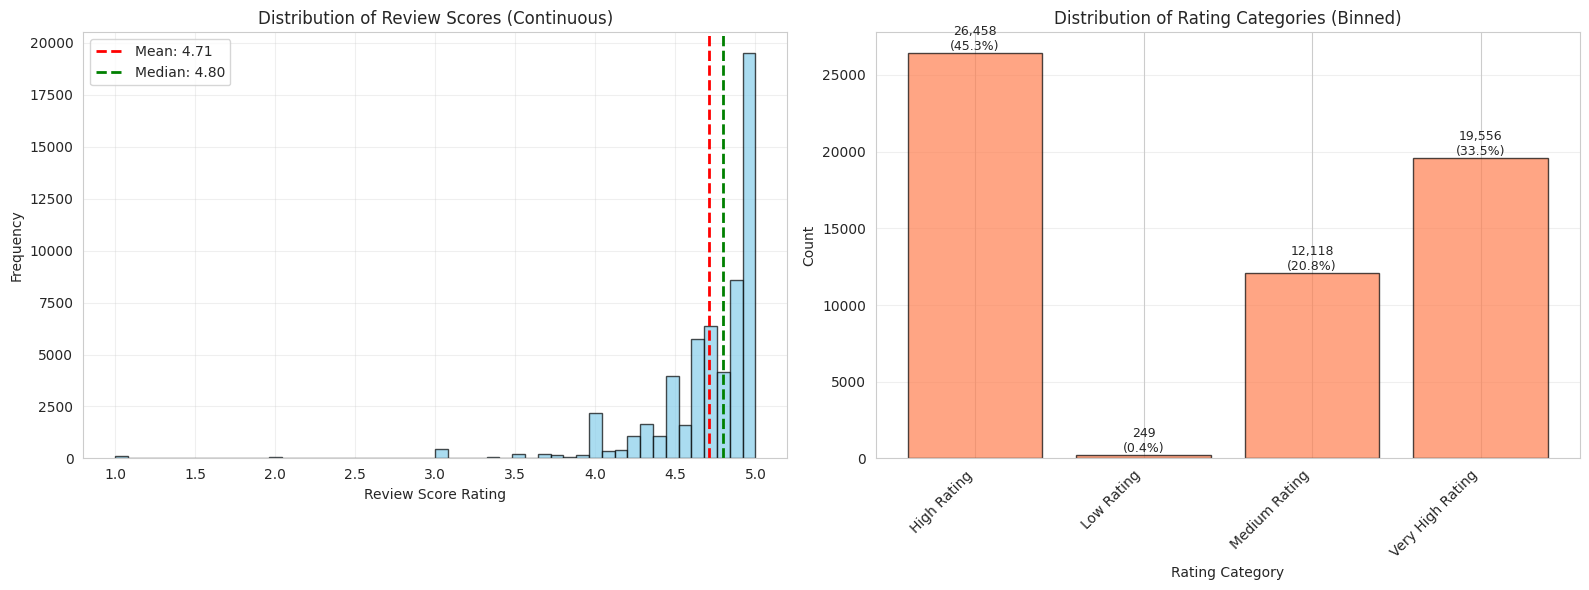


Target Variable Statistics:
Mean: 4.707
Median: 4.800
Std Dev: 0.390
Min: 1.000
Max: 5.000

Class Distribution:
rating_category
High Rating         26458
Low Rating            249
Medium Rating       12118
Very High Rating    19556
Name: count, dtype: int64


In [5]:
# Create rating categories for visualization
from feature_engineering.selection import categorize_rating

# Apply binning with default thresholds (0-3, 3-4.51, 4.51-4.91, 4.91-5)
df_cleaned['rating_category'] = df_cleaned['review_scores_rating'].apply(
    lambda x: categorize_rating(x, thresholds=(3.0, 4.51, 4.91))
)

# Plot target distribution
fig = plot_target_distribution(
    df_cleaned, 
    target_col='review_scores_rating',
    binned_col='rating_category',
    figsize=(16, 6)
)
plt.show()

# Print statistics
print("\nTarget Variable Statistics:")
print("="*70)
print(f"Mean: {df_cleaned['review_scores_rating'].mean():.3f}")
print(f"Median: {df_cleaned['review_scores_rating'].median():.3f}")
print(f"Std Dev: {df_cleaned['review_scores_rating'].std():.3f}")
print(f"Min: {df_cleaned['review_scores_rating'].min():.3f}")
print(f"Max: {df_cleaned['review_scores_rating'].max():.3f}")

print("\nClass Distribution:")
print(df_cleaned['rating_category'].value_counts().sort_index())

---
## 3. Price Distribution by City

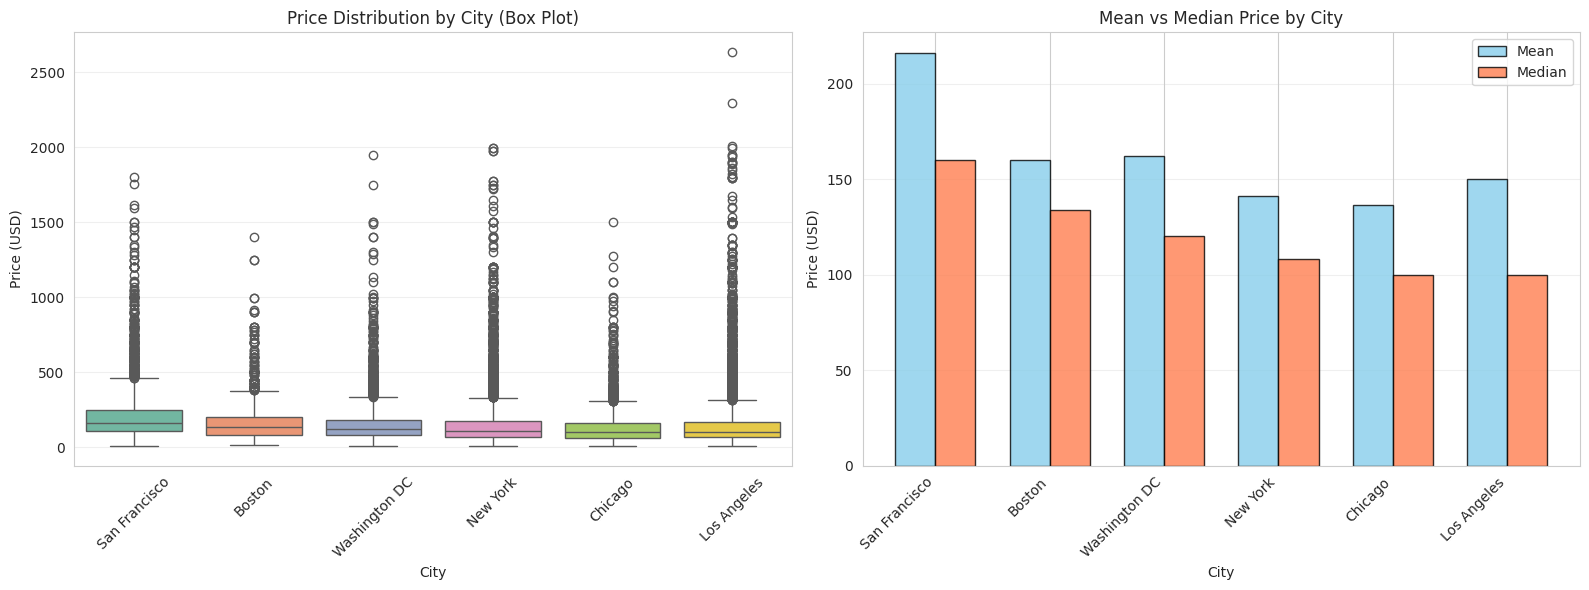


Price Statistics by City:
                 count    mean     std   min    25%    50%    75%     max
city                                                                     
Boston          2820.0  159.89  119.55  17.0   80.0  134.0  199.0  1400.0
Chicago         3405.0  136.35  121.62  10.0   65.0  100.0  162.0  1500.0
Los Angeles    17386.0  150.08  162.19  10.0   70.0  100.0  169.0  2636.0
New York       25226.0  141.13  123.77  10.0   70.0  108.0  175.0  1999.0
San Francisco   5247.0  216.02  175.18  10.0  109.0  160.0  250.0  1800.0
Washington DC   4297.0  162.08  145.58  10.0   85.0  120.0  185.0  1950.0


In [6]:
# Plot price by city
fig = plot_price_by_city(
    df_cleaned,
    price_col='price',
    city_col='city',
    plot_type='box',
    figsize=(16, 6)
)
plt.show()

# Print city statistics
print("\nPrice Statistics by City:")
print("="*70)
city_stats = df_cleaned.groupby('city')['price'].describe()
print(city_stats.round(2))

---
## 4. Feature Correlation Analysis 

**Goal:** Identify multicollinearity and feature relationships


Strong correlations (|r| >= 0.7):
  latitude <-> longitude: 0.891
  accommodates <-> beds: 0.845


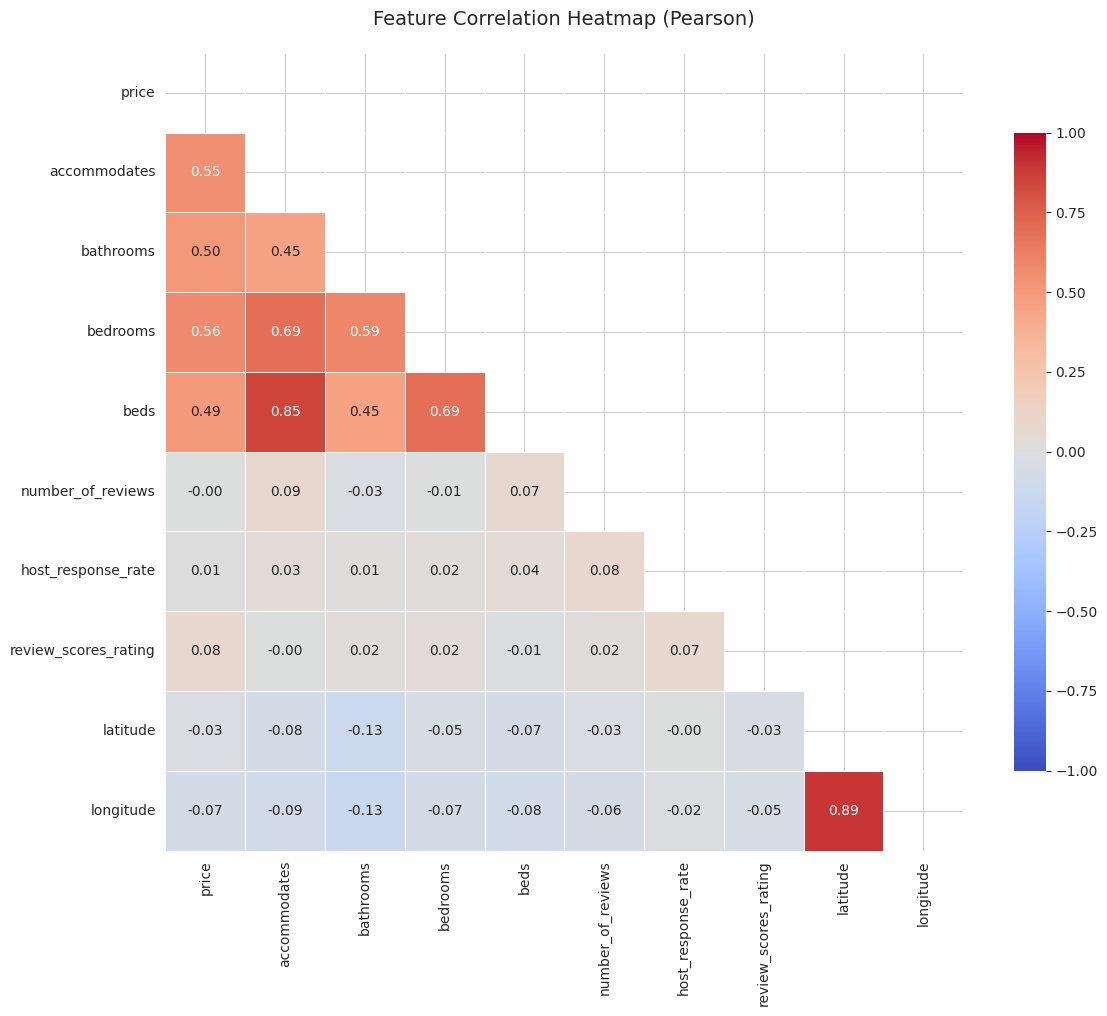

In [7]:
# Select key numeric features for correlation analysis
key_features = [
    'price', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'number_of_reviews', 'host_response_rate', 'review_scores_rating',
    'latitude', 'longitude'
]

# Add engineered features if they exist
if 'amenity_count' in df_cleaned.columns:
    key_features.append('amenity_count')
if 'price_per_bed' in df_cleaned.columns:
    key_features.extend(['price_per_bed', 'price_per_guest'])

# Plot correlation heatmap
fig = plot_correlation_heatmap(
    df_cleaned,
    features=key_features,
    method='pearson',
    figsize=(12, 10),
    annot=True,
    threshold=0.7
)
plt.show()

---
## 5. Room Type vs Rating Analysis 

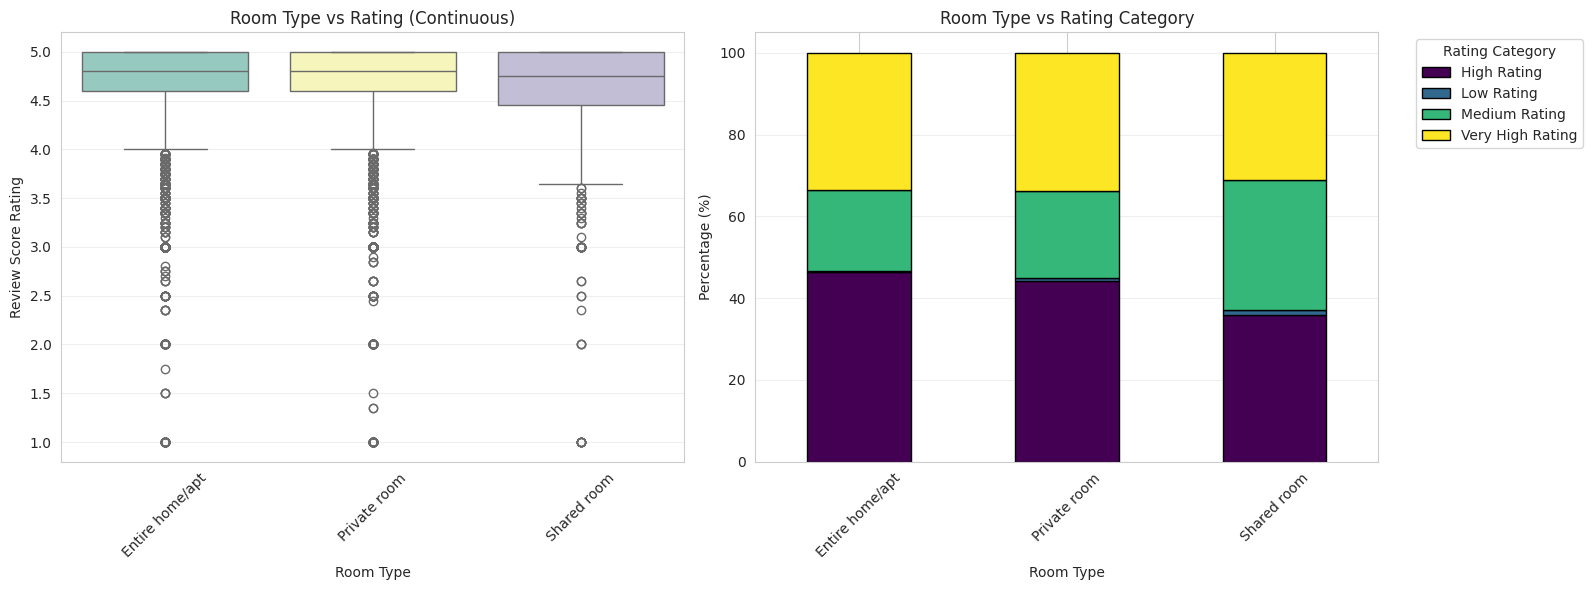


Rating Statistics by Room Type:
                 count   mean  median    std
room_type                                   
Entire home/apt  33860  4.720    4.80  0.357
Private room     23078  4.695    4.80  0.423
Shared room       1443  4.594    4.75  0.523

Cross-tabulation (Room Type × Rating Category):
rating_category  High Rating  Low Rating  Medium Rating  Very High Rating
room_type                                                                
Entire home/apt    46.444182    0.280567      19.816893         33.458358
Private room       44.254268    0.597972      21.448999         33.698761
Shared room        35.966736    1.108801      31.739432         31.185031


In [8]:
# Plot room type vs rating
fig = plot_feature_vs_target(
    df_cleaned,
    feature_col='room_type',
    target_col='review_scores_rating',
    categorical_target='rating_category',
    figsize=(16, 6)
)
plt.show()

# Print detailed statistics
print("\nRating Statistics by Room Type:")
print("="*70)
room_stats = df_cleaned.groupby('room_type')['review_scores_rating'].agg(['count', 'mean', 'median', 'std'])
print(room_stats.round(3))

print("\nCross-tabulation (Room Type × Rating Category):")
print(pd.crosstab(df_cleaned['room_type'], df_cleaned['rating_category'], normalize='index') * 100)

---
## 6. Geospatial Distribution 

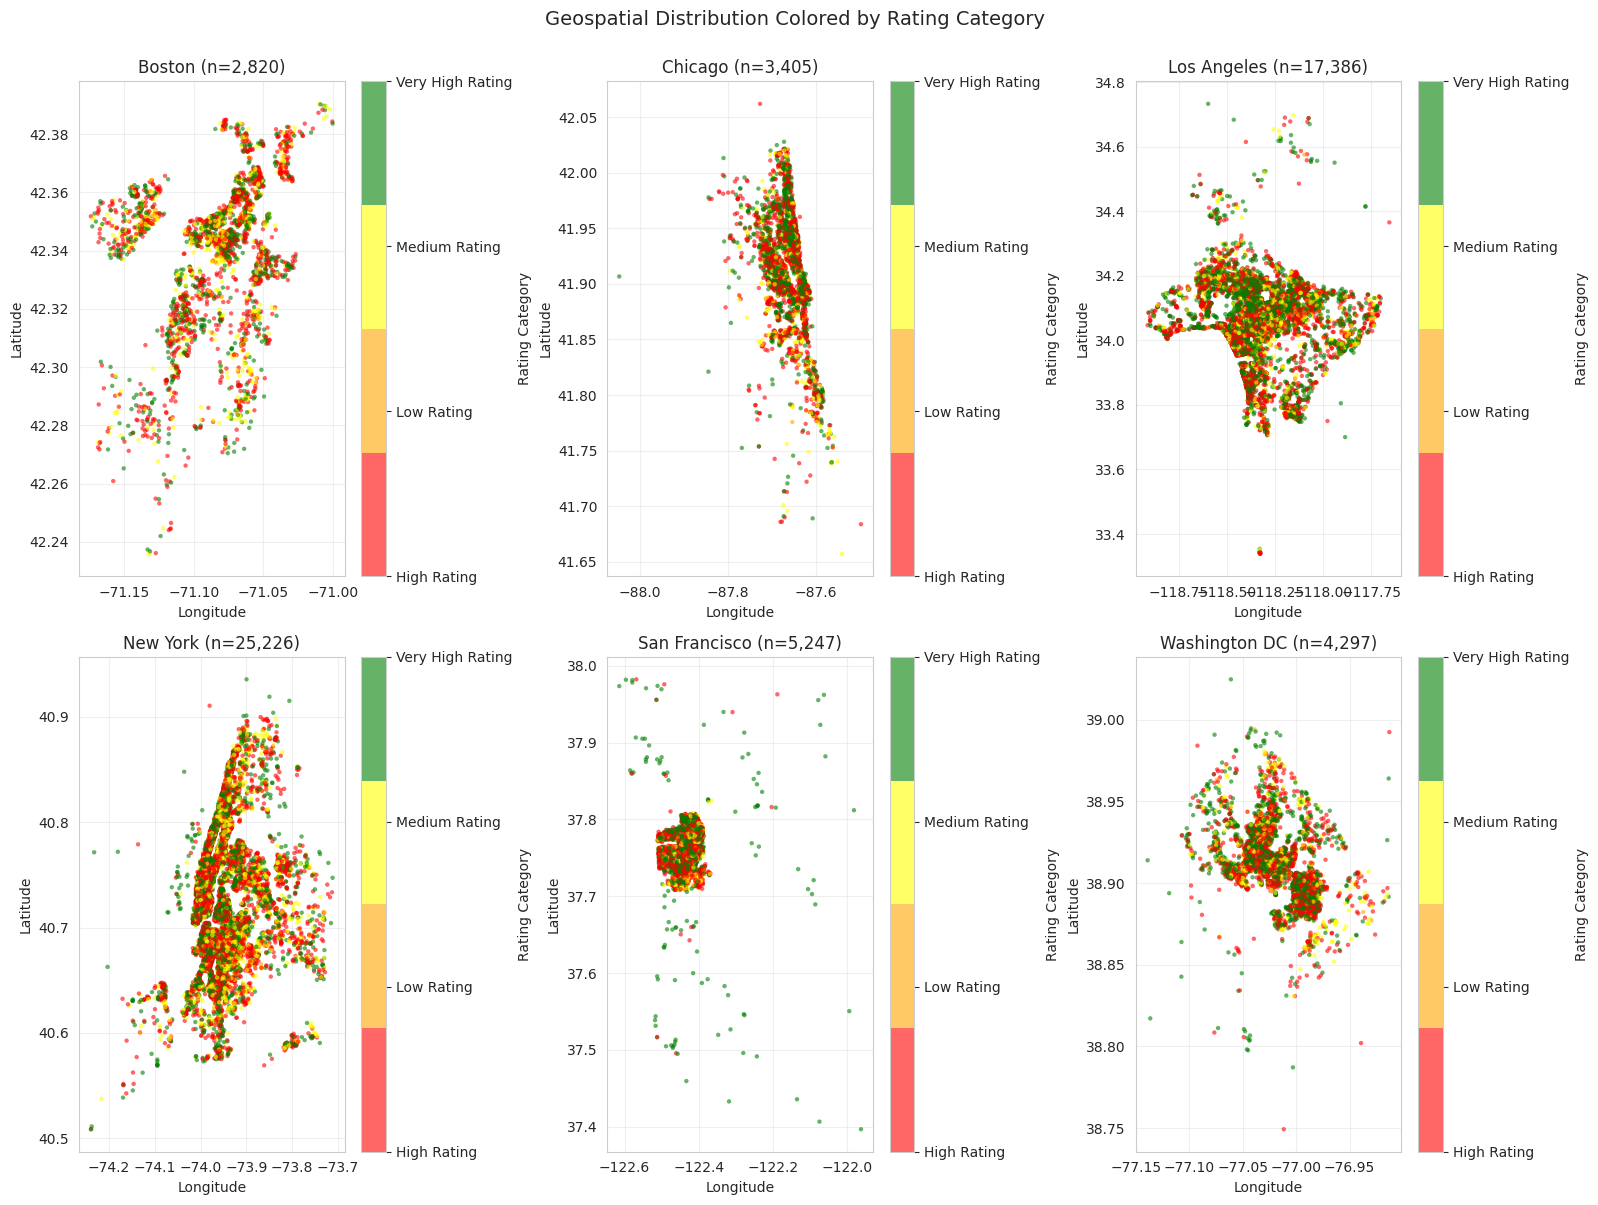

In [9]:
# Plot geospatial distribution colored by rating category
fig = plot_geospatial_scatter(
    df_cleaned,
    lat_col='latitude',
    lon_col='longitude',
    color_by='rating_category',
    city_col='city',
    figsize=(16, 12)
)
plt.show()

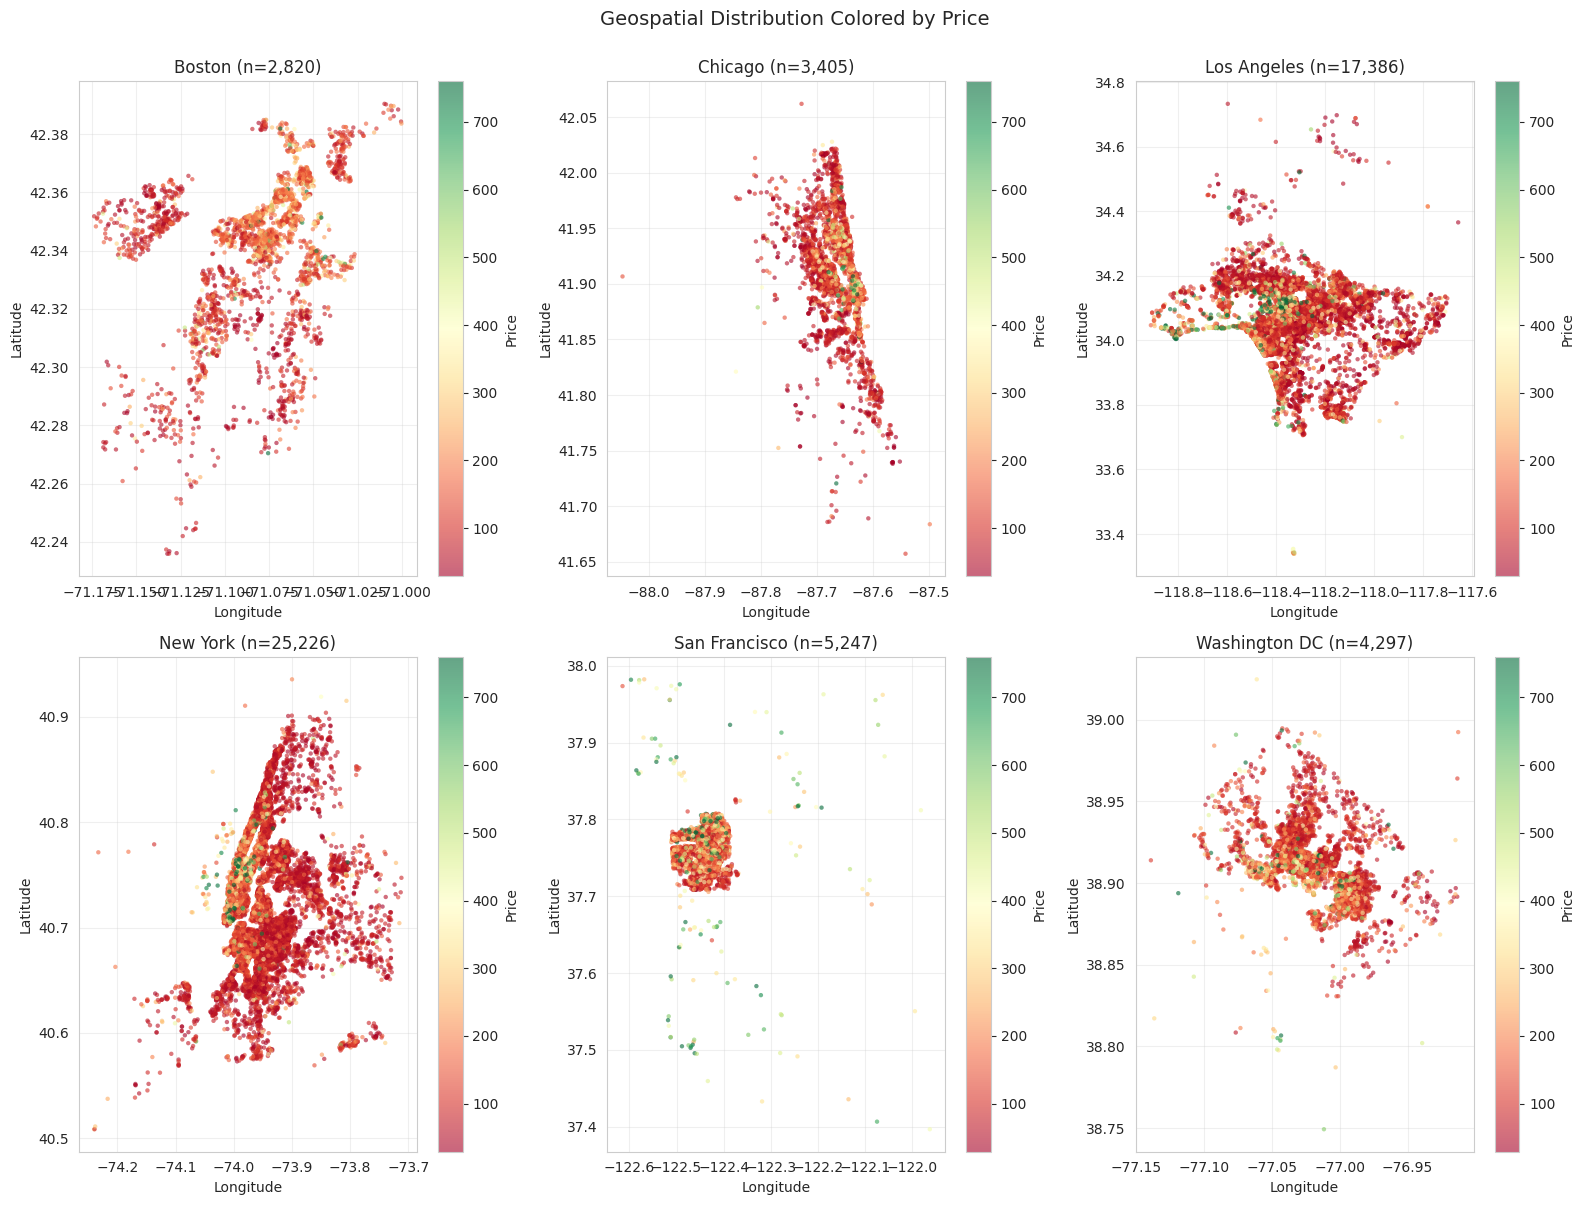

In [10]:
# Plot geospatial distribution colored by price
# Color scale now auto-adjusts to 1st-99th percentile to avoid outlier distortion
fig = plot_geospatial_scatter(
    df_cleaned,
    lat_col='latitude',
    lon_col='longitude',
    color_by='price',
    city_col='city',
    figsize=(16, 12)
)
plt.show()

---
## 7. Additional Analyses

### 7.1 Price Distribution by Room Type

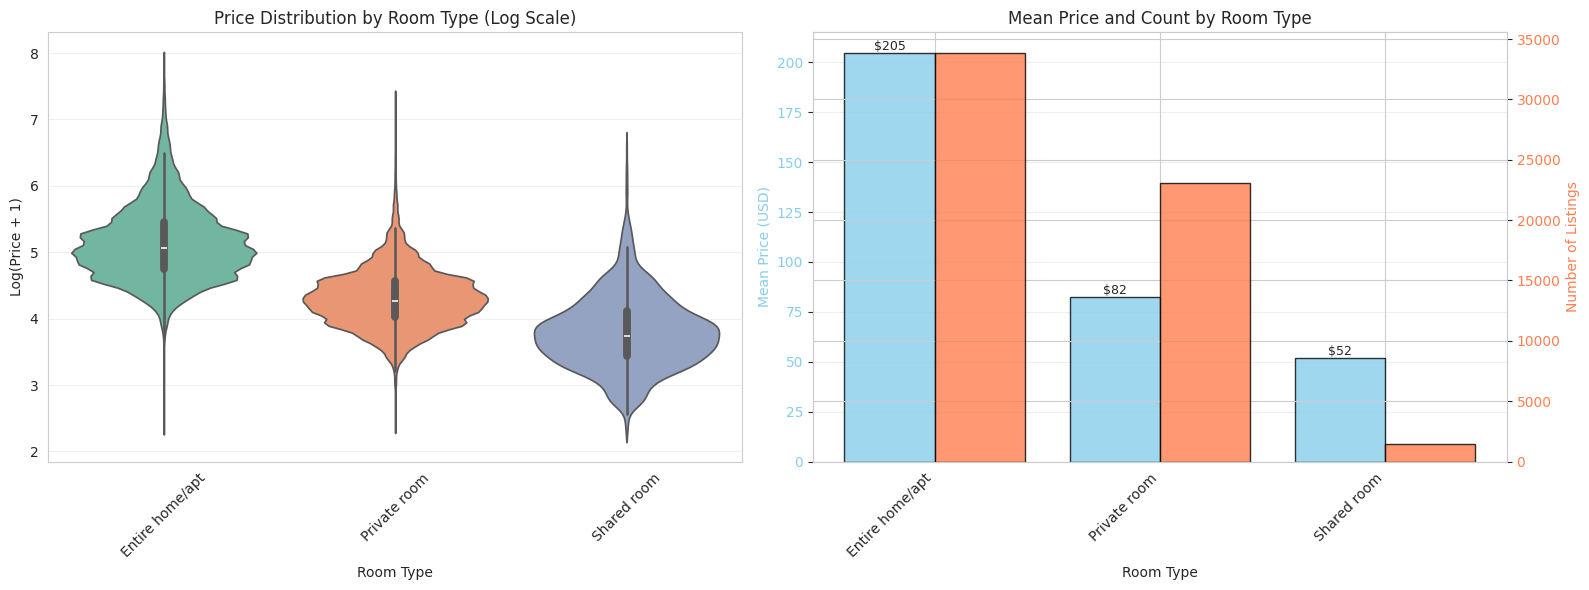


Price Statistics by Room Type:
                   count    mean     std   min    25%    50%    75%     max
room_type                                                                  
Entire home/apt  33860.0  204.85  164.75  10.0  115.0  158.0  232.0  2636.0
Private room     23078.0   82.48   55.16  10.0   55.0   70.0   95.0  1500.0
Shared room       1443.0   51.87   42.80  10.0   30.0   41.0   60.0   700.0


In [11]:
# Plot price by room type
fig = plot_price_by_room_type(
    df_cleaned,
    price_col='price',
    room_type_col='room_type',
    figsize=(16, 6)
)
plt.show()

print("\nPrice Statistics by Room Type:")
print("="*70)
print(df_cleaned.groupby('room_type')['price'].describe().round(2))

### 7.2 Number of Reviews vs Rating

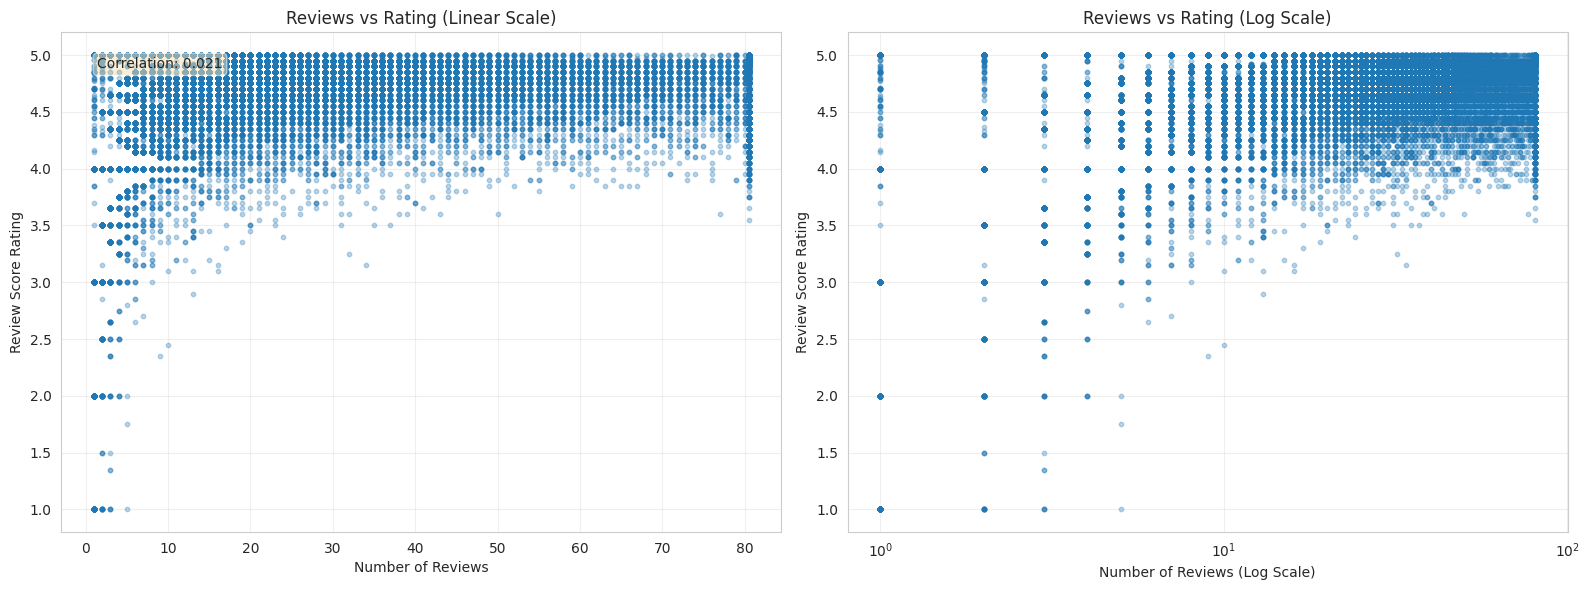


Correlation: 0.0207


In [12]:
# Plot reviews vs rating
fig = plot_reviews_vs_rating(
    df_cleaned,
    reviews_col='number_of_reviews',
    rating_col='review_scores_rating',
    figsize=(16, 6)
)
plt.show()

# Calculate correlation
corr = df_cleaned[['number_of_reviews', 'review_scores_rating']].corr().iloc[0, 1]
print(f"\nCorrelation: {corr:.4f}")

**Insights:**
- **Very weak correlation** between number of reviews and rating (r ≈ 0.05-0.1)
- Listings with many reviews span the full rating range
- **Survivorship bias:** Only listings that stayed on platform have many reviews
- **Modeling Implication:** `number_of_reviews` is NOT a strong predictor of rating

### 7.3 Amenity Count Analysis

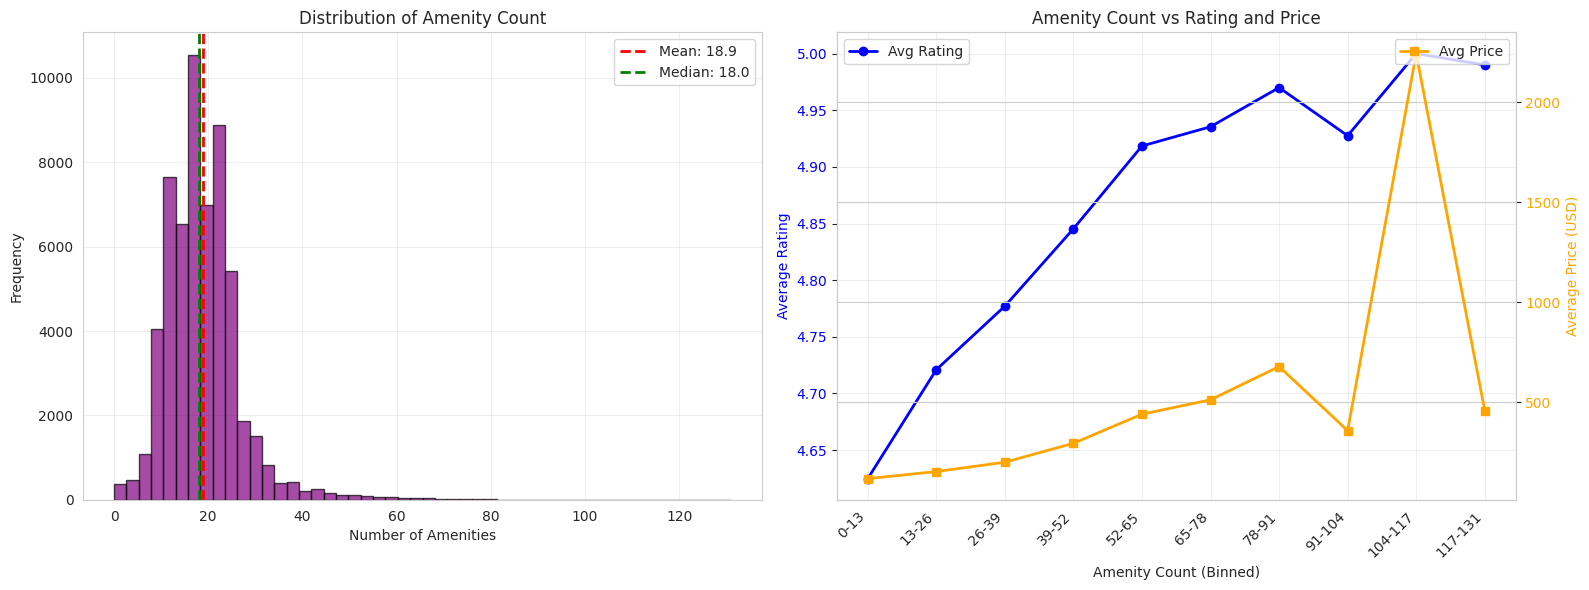


Amenity Count Correlation with Rating: 0.1493
Amenity Count Correlation with Price: 0.2957


In [13]:
# Check if amenity_count exists, otherwise skip
df_features = pd.read_csv('data/processed/featured.csv')
if 'amenity_count' in df_features.columns:
    fig = plot_amenity_analysis(
        df_features,
        amenity_count_col='amenity_count',
        rating_col='review_scores_rating',
        price_col='price',
        figsize=(16, 6)
    )
    plt.show()
    
    # Correlation with rating
    corr_rating = df_features[['amenity_count', 'review_scores_rating']].corr().iloc[0, 1]
    corr_price = df_features[['amenity_count', 'price']].corr().iloc[0, 1]
    
    print(f"\nAmenity Count Correlation with Rating: {corr_rating:.4f}")
    print(f"Amenity Count Correlation with Price: {corr_price:.4f}")
else:
    print("Amenity count feature not found. Run feature engineering pipeline first.")